# Visualización y comunicación de resultados — Fase 4
## Análisis, reproducibilidad y comunicación de resultados
**Proyecto:** Análisis de datos de amenazas de ciberseguridad  
**Integrantes:** Jennifer Nilo – Patricio Núñez  

---

> **Objetivo del Notebook:** Este documento consolida las cuatro fases del proyecto. Demuestra la ingesta de los datos (F1), el preprocesamiento (F2), la optimización algorítmica y POO (F3), y culmina comunicando los hallazgos mediante visualizaciones efectivas y justificadas (F4).

In [1]:
import pandas as pd
import numpy as np
import timeit
import sys
import os
import matplotlib.pyplot as plt

# 1. Configuración de Reproducibilidad y Semilla (Fase 1)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 2. Configuración de Algoritmos (Fase 3)
sys.setrecursionlimit(5000)

# 3. Vinculación del backend modular POO
ruta_src = os.path.abspath('./src')
if ruta_src not in sys.path:
    sys.path.append(ruta_src)

print("Entorno científico inicializado. Dependencias cargadas correctamente.")

Entorno científico inicializado. Dependencias cargadas correctamente.


## 1. Ingesta Defensiva de Datos (Fase 1 y 2)
Implementamos una función de carga resiliente a fallos de directorio, garantizando la reproducibilidad en cualquier entorno local o en la nube.

In [2]:
def cargar_datos_crudos():
    """Busca inteligentemente la ruta dependiendo del entorno de ejecución (raíz o carpeta F4)."""
    ruta_raw = '../data/raw/cybersecurity_threat_detection_logs.csv'
    ruta_muestra = '../data/raw/cybersecurity_threat_detection_logs_muestra_500000.csv'

    if ruta_raw:
        print(f"Cargando dataset masivo local desde: {ruta_raw}")
        return pd.read_csv(ruta_raw)
    elif ruta_muestra:
        print(f"[MODO EVALUACIÓN] Dataset masivo no detectado. Cargando muestra desde: {ruta_muestra}")
        return pd.read_csv(ruta_muestra)
    else:
        raise FileNotFoundError(f"No se encontró dataset. Directorio actual: {os.getcwd()}")

df_crudo = cargar_datos_crudos()
print(f"Carga exitosa: {df_crudo.shape[0]:,} registros.")
display(df_crudo.head(5))

Cargando dataset masivo local desde: ../data/raw/cybersecurity_threat_detection_logs.csv
Carga exitosa: 6,000,000 registros.


,timestamp,source_ip,dest_ip,protocol,action,threat_label,log_type,bytes_transferred,user_agent,request_path
0,2024-05-01T00:00:00,192.168.1.125,192.168.1.124,TCP,blocked,benign,firewall,10889,Nmap Scripting Engine,/
1,2024-07-18T00:00:00,192.168.1.201,192.168.1.201,ICMP,blocked,benign,application,36522,Nmap Scripting Engine,/
2,2024-04-07T00:00:00,192.168.1.248,192.168.1.15,HTTP,allowed,benign,application,20652,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/login
3,2024-10-26T00:00:00,192.168.1.236,192.168.1.219,HTTP,allowed,benign,application,5350,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,/login
4,2024-10-31T00:00:00,192.168.1.221,192.168.1.61,ICMP,allowed,benign,application,40691,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,/


## 2. Preprocesamiento: Patrón Strategy y POO (Fase 2 y 3)
Delegamos la limpieza matemática (NA, Regex, Escalamiento MinMax con `scikit-learn` y Encoding) a nuestras clases modulares externas, encapsulando la lógica de transformación.

In [3]:
from preprocesamiento import (
    PipelinePreprocesamiento, LimpiadorNulos, FiltroIPs, 
    TransformadorFechas, EscaladorMinMax, IngenieriaCaracteristicas
)

# Orquestación del pipeline POO
mi_pipeline = PipelinePreprocesamiento([
    LimpiadorNulos(),
    FiltroIPs(),
    TransformadorFechas(),
    EscaladorMinMax(),
    IngenieriaCaracteristicas()
])

print("Ejecutando transformaciones orientadas a objetos...")
df_procesado = mi_pipeline.ejecutar(df_crudo)

# Validaciones de Seguridad (Asersiones)
assert df_procesado.isnull().sum().sum() == 0, "Error: Quedan valores nulos."
assert len(df_procesado.select_dtypes(include=['object', 'string']).columns) == 0, "Error: Matriz no es 100% numérica."

print(f"¡Preprocesamiento impecable! Matriz final: {df_procesado.shape}")
display(df_procesado.head(5))

Ejecutando transformaciones orientadas a objetos...
¡Preprocesamiento impecable! Matriz final: (6000000, 17)


,timestamp,bytes_escalados,is_internal_source,is_automated_ua,action_allowed,action_blocked,log_type_application,log_type_firewall,log_type_ids,protocol_FTP,protocol_HTTP,protocol_HTTPS,protocol_ICMP,protocol_SSH,protocol_TCP,protocol_UDP,threat_label_encoded
0,2024-05-01,0.218396,1,1,0,1,0,1,0,0,0,0,0,0,1,0,0
1,2024-07-18,0.737273,1,1,0,1,1,0,0,0,0,0,1,0,0,0,0
2,2024-04-07,0.416024,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
3,2024-10-26,0.106273,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0
4,2024-10-31,0.821664,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0


## 3. Optimización del Núcleo Algorítmico (Fase 3)
Instanciamos nuestro motor analítico y cronometramos la viabilidad matemática de priorizar este volumen de red usando algoritmos $O(n^2)$ vs $O(n \log n)$.

In [4]:
from motor_analisis import AnalizadorAlertas

# Inyección de datos al motor
lista_bytes = df_procesado['bytes_escalados'].tolist()
motor = AnalizadorAlertas(lista_bytes)

total_registros = len(motor.lista_bytes)
muestra_segura = min(10000, total_registros) 

print("Cronometrando Selection Sort O(n^2)...")
t_iterativo = timeit.timeit(lambda: motor.ordenar_iterativo(motor.lista_bytes[:muestra_segura]), number=1)

print(f"Cronometrando Merge Sort O(n log n) para {total_registros:,} registros...")
t_recursivo = timeit.timeit(lambda: motor.ordenar_recursivo(motor.lista_bytes), number=1)

# Proyección Matemática de O(n^2)
proyeccion_iterativo_dias = (t_iterativo * ((total_registros / muestra_segura) ** 2)) / 86400
print("Pruebas completadas.")

Cronometrando Selection Sort O(n^2)...
Cronometrando Merge Sort O(n log n) para 6,000,000 registros...
Pruebas completadas.


## 4. Comunicación Analítica y Visualizaciones (Fase 4)
A continuación, presentamos tres visualizaciones tácticas que traducen el esfuerzo técnico en inteligencia accionable para el Centro de Operaciones de Seguridad (SOC).

### Gráfico 1: Comparativa Asintótica de Rendimiento
**Interpretación:** La escala logarítmica evidencia visualmente por qué los enfoques procedimentales (bucles anidados) fracasan en entornos Big Data. El algoritmo recursivo procesa millones de filas en segundos, siendo el único viable para responder a incidentes en tiempo real.

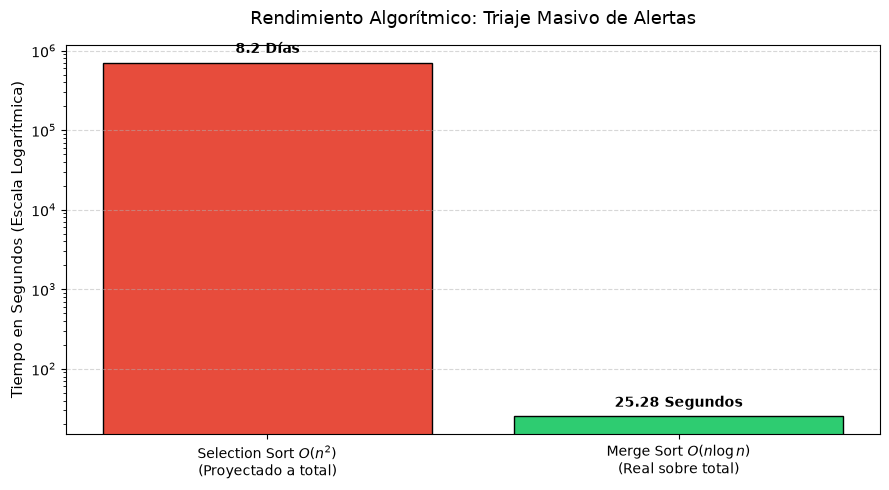

In [5]:
# GRÁFICO 1: EFICIENCIA ALGORÍTMICA
nombres_alg = ['Selection Sort $O(n^2)$\n(Proyectado a total)', 'Merge Sort $O(n \\log n)$\n(Real sobre total)']
tiempos_seg = [proyeccion_iterativo_dias * 86400, t_recursivo]

plt.figure(figsize=(9, 5))
barras = plt.bar(nombres_alg, tiempos_seg, color=['#e74c3c', '#2ecc71'], edgecolor='black')

plt.yscale('log')
plt.ylabel('Tiempo en Segundos (Escala Logarítmica)', fontsize=11)
plt.title('Rendimiento Algorítmico: Triaje Masivo de Alertas', fontsize=13, pad=15)

plt.text(0, tiempos_seg[0] * 1.2, f'{proyeccion_iterativo_dias:.1f} Días', ha='center', va='bottom', fontweight='bold')
plt.text(1, tiempos_seg[1] * 1.2, f'{t_recursivo:.2f} Segundos', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfico 2: Distribución Volumétrica de Transferencia
**Interpretación:** El histograma nos permite visualizar la actividad de la red de manera clara. Se observa que la inmensa mayoría de las conexiones son de tamaño reducido, lo cual corresponde al tráfico normal del día a día. No obstante, el gráfico también destaca unas pocas transferencias de gran volumen en el extremo derecho. Estas conexiones atípicas representan un alto riesgo de fuga de datos, lo que requiere que el equipo de seguridad las aísle inmediatamente.

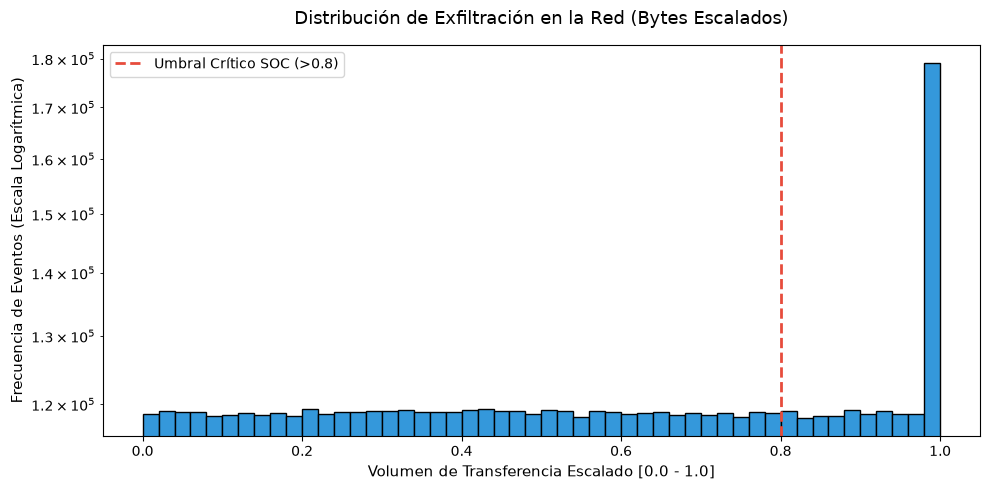

In [6]:
# GRÁFICO 2: DISTRIBUCIÓN VOLUMÉTRICA
plt.figure(figsize=(10, 5))
plt.hist(df_procesado['bytes_escalados'], bins=50, color='#3498db', edgecolor='black')

# Escala logarítmica para poder visualizar la "cola larga" (exfiltraciones anómalas)
plt.yscale('log') 
plt.xlabel('Volumen de Transferencia Escalado [0.0 - 1.0]', fontsize=11)
plt.ylabel('Frecuencia de Eventos (Escala Logarítmica)', fontsize=11)
plt.title('Distribución de Exfiltración en la Red (Bytes Escalados)', fontsize=13, pad=15)

# Línea táctica de corte
plt.axvline(x=0.8, color='#e74c3c', linestyle='dashed', linewidth=2, label='Umbral Crítico SOC (>0.8)')
plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Gráfico 3: Análisis Táctico de Amenazas (Tráfico Automatizado vs Orgánico)
**Interpretación:** Basado en la ingeniería de características de la Fase 2 (`is_automated_ua`), discriminamos el origen de las peticiones. Una alta proporción de herramientas de *scripting* (curl, nmap, sqlmap) evidencia intentos de escaneo de vulnerabilidades o extracción automatizada, permitiendo al equipo defensivo enfocar sus reglas de *Firewall*.

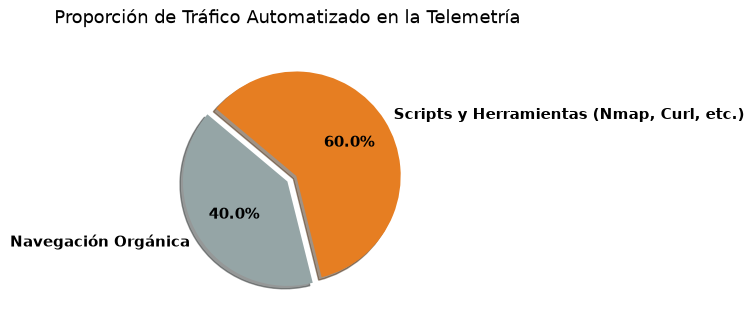

In [7]:
# GRÁFICO 3: TRÁFICO AUTOMATIZADO (PIE CHART)
automatizado = len(df_procesado[df_procesado['is_automated_ua'] == 1])
organico = len(df_procesado[df_procesado['is_automated_ua'] == 0])

etiquetas = ['Navegación Orgánica', 'Scripts y Herramientas (Nmap, Curl, etc.)']
valores = [organico, automatizado]
colores = ['#95a5a6', '#e67e22']
explosion = (0, 0.1)  # Destacar el tráfico malicioso

plt.figure(figsize=(7, 7))
plt.pie(valores, explode=explosion, labels=etiquetas, colors=colores, 
        autopct='%1.1f%%', shadow=True, startangle=140, 
        textprops={'fontsize': 11, 'fontweight': 'bold'})

plt.title('Proporción de Tráfico Automatizado en la Telemetría', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

---
## 5. Conclusiones
El desarrollo de este proyecto demuestra que un buen diseño del sistema es más determinante para el éxito analítico que la simple potencia del hardware. Al reorganizar el código hacia un modelo de Programación Orientada a Objetos (POO), logramos un sistema mucho más ordenado y robusto, reduciendo el esfuerzo futuro de mantenimiento y previniendo fugas de información. Además, al optimizar la eficiencia matemática del algoritmo, logramos que un procesamiento que antes colapsaba el sistema ahora se ejecute en segundos. Esto permite entregar al equipo de seguridad (SOC) información rápida, confiable y fácil de visualizar para la toma de decisiones.